Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


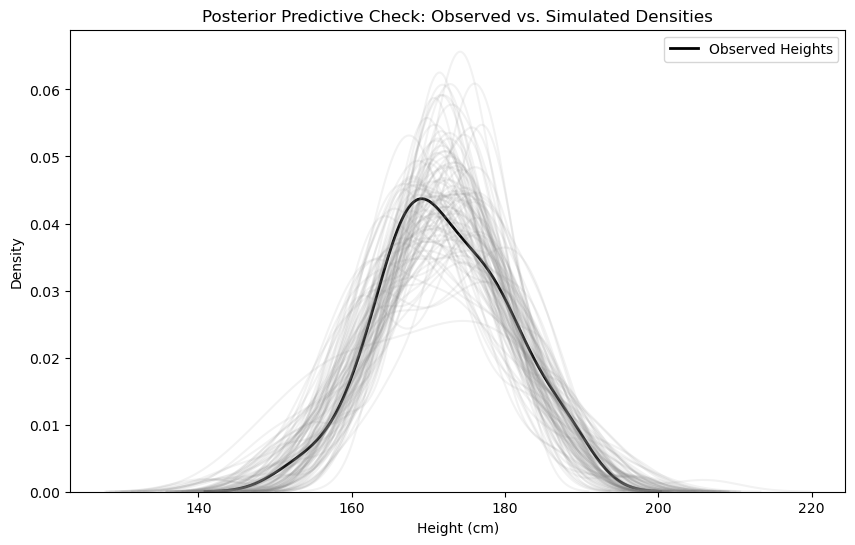

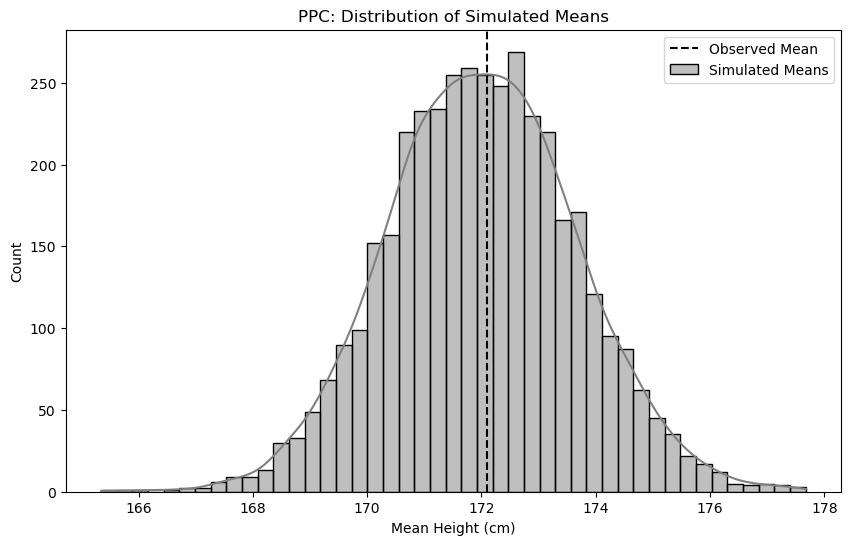

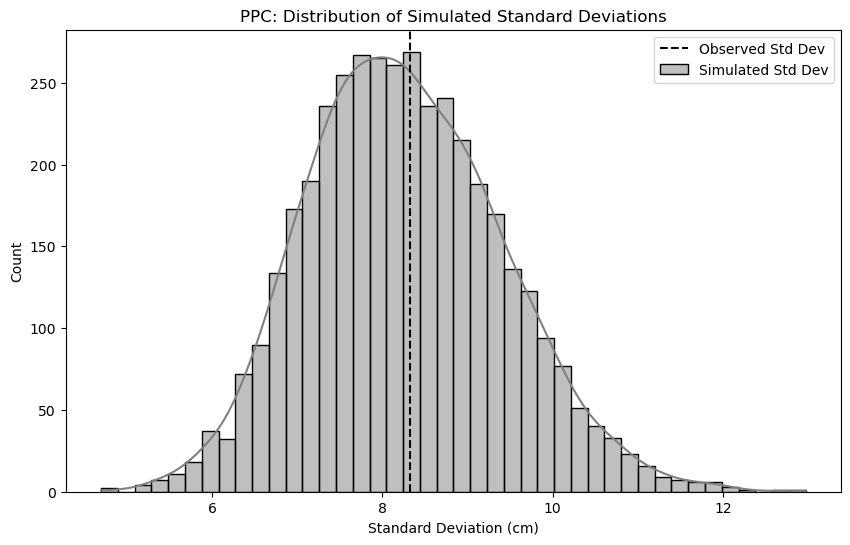

Bayesian p-value for mean: 0.480


In [1]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Observed heights

observed_heights = [164.4,  178.98, 173.98, 161.46, 167.95, 183.56, 155.01, 169.,   180.86, 165.93, \
 167.25, 171.34, 182.44, 167.53, 168.89, 168.96, 187.44, 187.31, 179.03, 174.7, \
 177.16, 182.44, 165.45, 180.23, 163.22, 167.54, 178.35, 162.,   171.02, 165.97, \
 170.21, 152.41, 159.6, 167.1,  178.49, 170.78, 172.02, 176.82, 165.84, 173.99, \
 166.36, 159.91, 169.26, 176.02, 174.37, 171.92, 188.75, 174.89, 178.85, 187.67]

# 2a. Infer the posterior distribution
with pm.Model() as model:
    # Prior for the population mean height
    mu = pm.Normal("mu", mu=170, sigma=10)

    # Prior for the population standard deviation (non-negative)
    sigma = pm.HalfNormal("sigma", sigma=5)

    # Likelihood
    heights = pm.Normal("heights", mu=mu, sigma=sigma, observed=observed_heights)

    # Sample from the posterior
    trace = pm.sample(1000, tune = 1000, return_inferencedata=True)

# 2b. Extract the posterior samples
posterior_samples = trace.posterior
posterior_mu = posterior_samples["mu"].values.flatten()
posterior_sigma = trace.posterior["sigma"].values.flatten()
# 2. Simulate fake posterior samples (replace with your actual MCMC samples)
#n_samples = 1000  # Number of posterior samples
# Fake posterior: mu ~ Normal(172, 1.5), sigma ~ Normal(7, 1) truncated to positive
#posterior_mu = np.random.normal(172, 1.5, n_samples)
#posterior_sigma = np.abs(np.random.normal(7, 1, n_samples))  # Ensure sigma > 0

# 3. Simulate posterior predictive data
n_samples = len(posterior_mu)
n = len(observed_heights)  # Number of observed heights
simulated_heights = np.zeros((n_samples, n))  # Array to store simulated datasets
for i in range(n_samples):
    # For each posterior sample (mu, sigma), simulate a dataset of n heights
    mu_i = posterior_mu[i]
    sigma_i = posterior_sigma[i]
    simulated_heights[i, :] = np.random.normal(mu_i, sigma_i, n)

# 4. Posterior Predictive Checks
# Plot 1: Density overlay (observed vs. simulated)
plt.figure(figsize=(10, 6))
sns.kdeplot(observed_heights, label="Observed Heights", color="black", linewidth=2)
for i in range(100):  # Plot a subset of simulated datasets
    sns.kdeplot(simulated_heights[i, :], color="gray", alpha=0.1)
plt.title("Posterior Predictive Check: Observed vs. Simulated Densities")
plt.xlabel("Height (cm)")
plt.legend()
plt.show()

# Plot 2: Test statistic (mean of each dataset)
observed_mean = np.mean(observed_heights)
simulated_means = np.mean(simulated_heights, axis=1)  # Mean of each simulated dataset
plt.figure(figsize=(10, 6))
sns.histplot(simulated_means, kde=True, label="Simulated Means", color="gray")
plt.axvline(observed_mean, color="black", linestyle="--", label="Observed Mean")
plt.title("PPC: Distribution of Simulated Means")
plt.xlabel("Mean Height (cm)")
plt.legend()
plt.show()

# Plot 3: Test statistic (standard deviation)
observed_std = np.std(observed_heights)
simulated_stds = np.std(simulated_heights, axis=1)  # Std of each simulated dataset
plt.figure(figsize=(10, 6))
sns.histplot(simulated_stds, kde=True, label="Simulated Std Dev", color="gray")
plt.axvline(observed_std, color="black", linestyle="--", label="Observed Std Dev")
plt.title("PPC: Distribution of Simulated Standard Deviations")
plt.xlabel("Standard Deviation (cm)")
plt.legend()
plt.show()

# 5. Bayesian p-value for mean
bayes_pval_mean = np.mean(simulated_means >= observed_mean)
print(f"Bayesian p-value for mean: {bayes_pval_mean:.3f}")